<a href="https://colab.research.google.com/github/arielsharonferdinandus/Credit-Card-Clients-Risk-Prediction/blob/data-preparation-and-exploratory-analysis/Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install -q ucimlrepo


# Predicting Customer Credit Card Default Risk from Historical Financial Data

**A Leakage-Aware, Imbalance-Aware, Reproducible Binary Classification Study**

---

**Dataset:** `default-of-credit-card-clients.csv` (UCI Machine Learning Repository — *Default of Credit Card Clients*, I-Cheng Yeh, 2016, DOI: 10.24432/C55S3E)

**Task type:** Binary classification

**Target:** `default payment next month` (0 = Non-default, 1 = Default)

---


## Executive Project Summary (Preliminary)

> This is a **preliminary** summary written before modeling. It states the problem, data, and
> methodological commitments up front so that the final Executive Summary deliverable can later
> extract these facts directly rather than reconstructing them after the fact. **No final results
> are stated here** — result values will only appear in later sections once they have actually
> been computed on held-out data.

- **Problem:** Predict whether a credit card client will default on their payment next month.
- **Dataset:** UCI *Default of Credit Card Clients* — 30,000 clients, 25 columns (23 numeric,
  2 categorical-coded-as-numeric: `SEX`, and jointly `EDUCATION`/`MARRIAGE`), Taiwan, 2005.
- **Target:** `default payment next month` — binary (0 = non-default, 1 = default).
- **Prediction timing:** The model must predict default risk *before* the due date of the target
  month, using only information available up to that point (demographics, credit limit, and the
  six most recent repayment-status/billing/payment records). No information from *after* the
  target month may be used — this is the central leakage constraint of the project (see the
  Leakage Audit and Data Preparation sections below).
- **Main modeling strategy:** Stratified train/validation/test split; scikit-learn `Pipeline` +
  `ColumnTransformer` for preprocessing fitted only on the training fold; a majority-class
  baseline, an interpretable Logistic Regression model, and a tree-based ensemble
  (Random Forest, optionally Gradient Boosting), compared on the validation set and evaluated
  once on the test set.
- **Primary metric:** F1-score for the positive class (Default = 1), because both missing a
  true default (false negative → credit loss) and flagging a good client (false positive →
  lost business) carry real cost, and F1 balances precision and recall on the minority class.
- **Key methodological constraints:**
  - `EDUCATION` contains undocumented codes (0, 5, 6) outside the documented 1–4 range.
  - `MARRIAGE` contains an undocumented code (0) outside the documented 1–3 range.
  - `PAY_0`…`PAY_6` contain sentinel values -2 and -1 that do **not** mean "very early
    payment" — they mean *no consumption / revolving balance* and *paid in full*, respectively,
    and must be interpreted semantically, not as ordinary integers.
  - All preprocessing parameters (scaler means/variances, one-hot categories) are fit
    **only** on the training split.
- **Class imbalance:** ~22.1% of clients defaulted (6,636 / 30,000); ~77.9% did not — an
  imbalance ratio of roughly 3.5 : 1, which makes raw accuracy a misleading metric (see the
  Target Distribution discussion below).
- **Expected stakeholder use:** A credit risk team could use validated default-probability
  estimates to prioritize review, adjust credit limits, or trigger proactive outreach for
  high-risk accounts — while treating the model's output as *predictive association*, not
  *proof of causation* (see the interpretation constraint described just above).


## Project Overview

### Business / problem context
Credit card issuers extend revolving credit and carry the risk that a cardholder will fail to
make the required payment in a given month. Being able to anticipate this risk before the due
date lets a financial institution intervene early — e.g., through credit-limit adjustment,
targeted reminders, or proactive collections — rather than reacting only after a client has
already defaulted.

### Predictive question
> *"Using historical billing, repayment status, and demographic information, can we identify
> credit card clients who are likely to default on their next month's payment?"*

### Task type
Binary classification. `default payment next month` ∈ {0, 1}.

### Unit of analysis
One credit card account holder (one row per client).

### Prediction timing
The model is trained to predict default risk **before** the payment due date of the target
month, using only demographic attributes and the six most recent months of repayment status,
bill statements, and payment amounts available *up to that point*. No feature may encode
information that would only be known *after* the target month's due date has passed.

### Definition of a positive prediction
`1` = the model predicts the client **will default** on next month's payment.
`0` = the model predicts the client **will not default**.

### What the model is NOT intended to claim
The model estimates a **statistical association** between a client's profile/history and the
probability of default. It does **not** establish that any feature — e.g., a repayment delay,
education level, or credit limit — *causes* default. Feature importance describes what the
model found *predictive* in this dataset, not a causal mechanism. Three distinct claims must
stay separated throughout this project:

1. **Predictive usefulness** — does the feature help the model discriminate defaulters from
   non-defaulters?
2. **Operational usefulness** — can a decision-maker act on the model's output in a way that
   plausibly reduces losses or improves outcomes?
3. **Causal interpretation** — does the feature *cause* the outcome? (Not established by this
   study; would require a causal design, e.g. quasi-experimental variation or intervention data.)

### Stakeholder value
A credit risk evaluation team can use a validated, well-calibrated classifier to flag
high-risk accounts early, informing credit-limit decisions and risk-mitigation outreach —
subject to fair-lending and regulatory review, since `SEX`, `EDUCATION`, and `MARRIAGE` are
protected or quasi-protected attributes in many jurisdictions.


## Dataset Description and Source

### Objective
Document exactly where the data came from, what it represents, and what each column means,
*before* touching the data programmatically — so every later decision can be traced back to a
documented source and a stated column definition.

### Source

| Field | Value |
|---|---|
| Dataset title | Default of Credit Card Clients |
| Publisher / owner | UCI Machine Learning Repository |
| Creator | I-Cheng Yeh |
| Official URL | https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients |
| DOI | 10.24432/C55S3E |
| Citation | Yeh, I. C. (2016). *Default of Credit Card Clients* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3E |
| Access date | 2026-09-26 |
| Local filename used | `default-of-credit-card-clients.csv` (exported from the supplied `.xls` file; values are unchanged) |
| Dataset dimensions (expected) | 30,000 rows × 25 columns |
| Observation unit | One credit card account holder |
| Target column | `default payment next month` |

### Predictor groups
- **Demographics:** `SEX`, `EDUCATION`, `MARRIAGE`, `AGE`
- **Credit line:** `LIMIT_BAL`
- **Repayment status (most recent 6 months):** `PAY_0`, `PAY_2`, `PAY_3`, `PAY_4`, `PAY_5`, `PAY_6`
- **Bill statements (most recent 6 months):** `BILL_AMT1`…`BILL_AMT6`
- **Previous payments (most recent 6 months):** `PAY_AMT1`…`PAY_AMT6`
- **Identifier (non-predictive):** `ID`

### Data dictionary
Built programmatically below from the loaded columns, and annotated with conceptual meaning,
role, and modeling decision.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd

# Reproducibility: fix the global random seed used throughout the notebook.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

# Table 2: Data dictionary and variable roles.
data_dictionary = pd.DataFrame([
    ("ID",         "int",  "Row identifier assigned by the data provider",                 "Identifier", "No",  "Non-predictive; would leak nothing but adds no signal and must never enter the feature matrix"),
    ("LIMIT_BAL",  "float","Amount of given credit (NT dollar), individual + family",       "Demographic/Credit", "Yes", ""),
    ("SEX",        "int",  "Gender (1 = male, 2 = female)",                                 "Demographic", "Yes", ""),
    ("EDUCATION",  "int",  "Education level (documented: 1=grad school,2=university,3=high school,4=others; undocumented: 0,5,6 observed)", "Demographic", "Yes", "Undocumented codes merged into 'Others' — see Data Quality Assessment"),
    ("MARRIAGE",   "int",  "Marital status (documented: 1=married,2=single,3=others; undocumented: 0 observed)", "Demographic", "Yes", "Undocumented code merged into 'Others' — see Data Quality Assessment"),
    ("AGE",        "int",  "Age in years",                                                  "Demographic", "Yes", ""),
    ("PAY_0",      "int",  "Repayment status, most recent month (Sept). -2=no consumption, -1=paid in full, 0=revolving credit used/paid minimum, 1..9=months delayed", "Repayment status", "Yes", ""),
    ("PAY_2",      "int",  "Repayment status, 1 month prior (Aug), same coding as PAY_0",    "Repayment status", "Yes", ""),
    ("PAY_3",      "int",  "Repayment status, 2 months prior (Jul)",                          "Repayment status", "Yes", ""),
    ("PAY_4",      "int",  "Repayment status, 3 months prior (Jun)",                          "Repayment status", "Yes", ""),
    ("PAY_5",      "int",  "Repayment status, 4 months prior (May)",                          "Repayment status", "Yes", ""),
    ("PAY_6",      "int",  "Repayment status, 5 months prior (Apr)",                          "Repayment status", "Yes", ""),
    ("BILL_AMT1",  "float","Bill statement amount, most recent month",                        "Bill statement", "Yes", ""),
    ("BILL_AMT2",  "float","Bill statement amount, 1 month prior",                             "Bill statement", "Yes", ""),
    ("BILL_AMT3",  "float","Bill statement amount, 2 months prior",                            "Bill statement", "Yes", ""),
    ("BILL_AMT4",  "float","Bill statement amount, 3 months prior",                            "Bill statement", "Yes", ""),
    ("BILL_AMT5",  "float","Bill statement amount, 4 months prior",                            "Bill statement", "Yes", ""),
    ("BILL_AMT6",  "float","Bill statement amount, 5 months prior",                            "Bill statement", "Yes", ""),
    ("PAY_AMT1",   "float","Amount paid, most recent month",                                   "Previous payment", "Yes", ""),
    ("PAY_AMT2",   "float","Amount paid, 1 month prior",                                        "Previous payment", "Yes", ""),
    ("PAY_AMT3",   "float","Amount paid, 2 months prior",                                       "Previous payment", "Yes", ""),
    ("PAY_AMT4",   "float","Amount paid, 3 months prior",                                       "Previous payment", "Yes", ""),
    ("PAY_AMT5",   "float","Amount paid, 4 months prior",                                       "Previous payment", "Yes", ""),
    ("PAY_AMT6",   "float","Amount paid, 5 months prior",                                       "Previous payment", "Yes", ""),
    ("default payment next month", "int (0/1)", "Target: did the client default on the following month's payment?", "Target", "Target (not a feature)", ""),
], columns=["column", "dtype", "conceptual_meaning", "role", "retained_for_modeling", "notes"])

data_dictionary


,column,dtype,conceptual_meaning,role,retained_for_modeling,notes
0,ID,int,Row identifier assigned by the data provider,Identifier,No,Non-predictive; would leak nothing but adds no...
1,LIMIT_BAL,float,"Amount of given credit (NT dollar), individual...",Demographic/Credit,Yes,
2,SEX,int,"Gender (1 = male, 2 = female)",Demographic,Yes,
3,EDUCATION,int,"Education level (documented: 1=grad school,2=u...",Demographic,Yes,Undocumented codes merged into 'Others' — see ...
4,MARRIAGE,int,"Marital status (documented: 1=married,2=single...",Demographic,Yes,Undocumented code merged into 'Others' — see D...
5,AGE,int,Age in years,Demographic,Yes,
6,PAY_0,int,"Repayment status, most recent month (Sept). -2...",Repayment status,Yes,
7,PAY_2,int,"Repayment status, 1 month prior (Aug), same co...",Repayment status,Yes,
8,PAY_3,int,"Repayment status, 2 months prior (Jul)",Repayment status,Yes,
9,PAY_4,int,"Repayment status, 3 months prior (Jun)",Repayment status,Yes,


## Data Loading and Initial Verification

### Objective
Establish, with programmatic evidence rather than assumption, that the data we are about to
analyze is in fact the correct dataset: the right name, the right shape, the right columns, the
right target — before any analysis is trusted. We also want the notebook to be runnable from a
fresh Colab session without manually uploading a file first.

### Method
Fetch the dataset **directly from its official source** using the UCI Machine Learning
Repository's own `ucimlrepo` client (`fetch_ucirepo(id=350)`, installed in the first cell of
this notebook), which pulls the canonical version of "Default of Credit Card Clients" straight
from `archive.ics.uci.edu` — the public, verifiable source cited above. The raw UCI
feature/target frames are then reassembled into a single DataFrame using the exact column names
this project documents, and the result is **verified programmatically** against the known
dataset facts (shape, target distribution) before it is trusted.

For reproducibility in environments without internet access (or if the UCI API is temporarily
unreachable), the fetched data is also saved to a local, relatively-pathed
`default-of-credit-card-clients.csv` — the required filename — and the notebook
automatically **falls back to that local copy** if the live fetch fails, so a transient network
issue never breaks reproducibility.

### Expected project directory structure
```
project/
├── Main.ipynb
├── default-of-credit-card-clients.csv   # written automatically on first successful fetch
└── README.md
```


In [3]:
# Portable, relative path resolution: works whether the notebook is run from
# Jupyter (cwd = notebook dir) or from `jupyter nbconvert --execute` elsewhere.
NOTEBOOK_DIR = Path.cwd()
DATA_PATH = NOTEBOOK_DIR / "default-of-credit-card-clients.csv"
TARGET_COL = "default payment next month"

# Canonical column order/names as documented in the project's data dictionary above.
# The ucimlrepo client sometimes returns generic names (X1..X23, Y); this mapping
# translates either the generic or descriptive UCI names to the exact names this
# project uses throughout, so downstream sections never depend on which naming
# convention the API happened to return.
UCI_GENERIC_TO_CANONICAL = {
    "X1": "LIMIT_BAL", "X2": "SEX", "X3": "EDUCATION", "X4": "MARRIAGE", "X5": "AGE",
    "X6": "PAY_0", "X7": "PAY_2", "X8": "PAY_3", "X9": "PAY_4", "X10": "PAY_5", "X11": "PAY_6",
    "X12": "BILL_AMT1", "X13": "BILL_AMT2", "X14": "BILL_AMT3",
    "X15": "BILL_AMT4", "X16": "BILL_AMT5", "X17": "BILL_AMT6",
    "X18": "PAY_AMT1", "X19": "PAY_AMT2", "X20": "PAY_AMT3",
    "X21": "PAY_AMT4", "X22": "PAY_AMT5", "X23": "PAY_AMT6",
    "Y": TARGET_COL, "Y1": TARGET_COL,
}
EXPECTED_FEATURE_COLS = [
    "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
]
EXPECTED_SHAPE = (30000, 25)  # including ID and the target column


def _standardize_columns(df):
    """Map generic UCI names (X1..X23, Y) to this project's canonical column names,
    leaving already-canonical names untouched."""
    return df.rename(columns={c: UCI_GENERIC_TO_CANONICAL.get(c, c) for c in df.columns})


def fetch_from_uci():
    """Fetch the dataset live from the UCI Machine Learning Repository (id=350).
    Returns a single reassembled DataFrame with canonical column names, or raises
    if the fetch or the resulting structure cannot be trusted."""
    from ucimlrepo import fetch_ucirepo

    dataset = fetch_ucirepo(id=350)
    X = _standardize_columns(dataset.data.features.copy())
    y = _standardize_columns(dataset.data.targets.copy())
    if y.shape[1] != 1:
        raise ValueError(f"Expected a single target column, got: {list(y.columns)}")
    y.columns = [TARGET_COL]

    # The official feature table separates 'ID' out with Role=ID rather than Feature;
    # ucimlrepo exposes it via .data.ids when present. Reconstruct it if available,
    # otherwise assign a sequential ID (ID itself is non-predictive either way — it is
    # dropped from the modeling feature set later regardless of its origin).
    ids = getattr(dataset.data, "ids", None)
    if ids is not None and len(ids) == len(X):
        id_series = _standardize_columns(ids.copy()).iloc[:, 0].rename("ID")
    else:
        id_series = pd.Series(range(1, len(X) + 1), name="ID")

    df = pd.concat([id_series.reset_index(drop=True), X.reset_index(drop=True),
                     y.reset_index(drop=True)], axis=1)

    missing_expected = set(EXPECTED_FEATURE_COLS) - set(df.columns)
    if missing_expected:
        raise ValueError(f"Fetched data is missing expected columns: {sorted(missing_expected)}")
    if df.shape != EXPECTED_SHAPE:
        raise ValueError(f"Fetched data shape {df.shape} != expected {EXPECTED_SHAPE}")

    return df, dataset.metadata, dataset.variables


data_source = None
try:
    raw_data, uci_metadata, uci_variables = fetch_from_uci()
    data_source = "UCI live fetch (ucimlrepo, id=350)"
    # Persist locally under the exact required filename, both for the reproducibility
    # fallback below and so a local copy of the dataset always exists on disk.
    raw_data.to_csv(DATA_PATH, index=False)
    print(f"[OK] Fetched dataset live from UCI and cached to: {DATA_PATH.name}")
except Exception as exc:
    print(f"[WARN] Live UCI fetch failed ({exc!r}); falling back to local cached copy.")
    assert DATA_PATH.exists(), (
        f"Live fetch failed AND no local fallback found at {DATA_PATH}. "
        "Either restore internet access, or place 'default-of-credit-card-clients.csv' "
        "in the same folder as this notebook."
    )
    raw_data = pd.read_csv(DATA_PATH)
    uci_metadata, uci_variables = None, None
    data_source = "local cached CSV (fallback)"

print(f"Data source used: {data_source}")
print(f"Shape: {raw_data.shape}")


[OK] Fetched dataset live from UCI and cached to: default-of-credit-card-clients.csv
Data source used: UCI live fetch (ucimlrepo, id=350)
Shape: (30000, 25)


In [4]:
# When the live fetch succeeded, print the official metadata/variable table returned
# by the UCI API itself -- this is the programmatic version of the source citation above.
if uci_metadata is not None:
    print("UCI metadata (selected fields):")
    for key in ["name", "repository_url", "doi", "abstract"]:
        if key in uci_metadata:
            print(f"  {key}: {uci_metadata[key]}")
    print()
    print("UCI variable table (as returned by the API):")
    display(uci_variables)
else:
    print("Running from the local cached CSV fallback; UCI metadata/variables were not "
          "re-fetched this run. The source citation above documents the same information.")


UCI metadata (selected fields):
  name: Default of Credit Card Clients
  repository_url: https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients
  abstract: This research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods.

UCI variable table (as returned by the API):


,name,role,type,demographic,description,units,missing_values
0,ID,ID,Integer,None,None,None,no
1,X1,Feature,Integer,None,LIMIT_BAL,None,no
2,X2,Feature,Integer,Sex,SEX,None,no
3,X3,Feature,Integer,Education Level,EDUCATION,None,no
4,X4,Feature,Integer,Marital Status,MARRIAGE,None,no
5,X5,Feature,Integer,Age,AGE,None,no
6,X6,Feature,Integer,None,PAY_0,None,no
7,X7,Feature,Integer,None,PAY_2,None,no
8,X8,Feature,Integer,None,PAY_3,None,no
9,X9,Feature,Integer,None,PAY_4,None,no


In [5]:
# Structural verification against the documented dataset facts (regardless of
# whether raw_data came from the live UCI fetch or the local fallback).
checks = {
    "shape is (30000, 25)": raw_data.shape == EXPECTED_SHAPE,
    "target column present": TARGET_COL in raw_data.columns,
    "ID column present": "ID" in raw_data.columns,
    "no fully-null columns": raw_data.isna().all().sum() == 0,
}
for description, passed in checks.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {description}")

assert all(checks.values()), "One or more structural checks failed — see printout above."


[PASS] shape is (30000, 25)
[PASS] target column present
[PASS] ID column present
[PASS] no fully-null columns


In [6]:
print("Column names:")
print(list(raw_data.columns))
print()
print("Data types:")
print(raw_data.dtypes)


Column names:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']

Data types:
ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      in

In [7]:
print("First rows:")
display(raw_data.head())
print("Last rows:")
display(raw_data.tail())


First rows:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


Last rows:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
29995,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,1
29999,30000,50000,1,2,1,46,0,0,0,0,0,0,47929,48905,49764,36535,32428,15313,2078,1800,1430,1000,1000,1000,1


In [8]:
raw_data.describe().T


,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


### Result
The loaded file matches the documented shape (30,000 × 25), contains the expected target column
`default payment next month`, and all 25 expected columns are present with numeric dtypes
(`ID` and the two nominal-but-numeric-coded fields `SEX`/`EDUCATION`/`MARRIAGE` included).

### Decision / implication
The file is verified as the correct dataset version. We proceed to a systematic data-quality
audit below before any modeling decision is made — nothing below this point should assume the
data is "clean" simply because it loaded without error.


## Data Quality Assessment

### Objective
Before fitting any model, establish *exactly* what is in the data: how many rows/columns, what
types, how much is missing, whether rows are duplicated, which categorical codes fall outside
the documented range, and — critically — whether any column could leak information from after
the prediction point. Each check below produces evidence that then drives a concrete decision
in the Data Preparation section that follows.


### Shape and Data Types

In [9]:
print(f"Rows: {raw_data.shape[0]:,}")
print(f"Columns: {raw_data.shape[1]}")
print()
numeric_cols = raw_data.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric-typed columns ({len(numeric_cols)}): {numeric_cols}")
print()
print("Note: SEX, EDUCATION, MARRIAGE are stored as numeric codes but are conceptually "
      "nominal/categorical variables — they will be one-hot encoded in the modeling pipeline, "
      "not treated as ordinal numbers.")


Rows: 30,000
Columns: 25

Numeric-typed columns (25): ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']

Note: SEX, EDUCATION, MARRIAGE are stored as numeric codes but are conceptually nominal/categorical variables — they will be one-hot encoded in the modeling pipeline, not treated as ordinal numbers.


### Missing Values
**Result:** the task specification states 0 raw missing values detected by pandas. We verify
this programmatically rather than trust the claim.

In [10]:
missing_table = pd.DataFrame({
    "missing_count": raw_data.isna().sum(),
    "missing_pct": (raw_data.isna().mean() * 100).round(3),
})
missing_table = missing_table[missing_table["missing_count"] > 0].sort_values("missing_count", ascending=False)
if missing_table.empty:
    print("No missing values detected in any column (0 / 0.000% across all 25 columns).")
else:
    display(missing_table)


No missing values detected in any column (0 / 0.000% across all 25 columns).


### Duplicate Rows

In [11]:
n_dupes = raw_data.duplicated().sum()
print(f"Exact duplicate rows: {n_dupes} ({n_dupes / len(raw_data):.3%} of rows)")


Exact duplicate rows: 0 (0.000% of rows)


**Decision:** No exact duplicate rows were found, so no de-duplication step is required.
(If duplicates existed, the decision would depend on whether `ID` values also repeated — a
repeated `ID` with identical feature values would indicate an ingestion artifact safe to drop;
distinct `ID`s with identical *features* could be legitimate coincidental matches and would need
closer inspection before removal.)

### Invalid / Undocumented Categories and Sentinel Values

The documented UCI coding is:
- `EDUCATION`: 1 = graduate school, 2 = university, 3 = high school, 4 = others (0, 5, 6 are
  **not** documented).
- `MARRIAGE`: 1 = married, 2 = single, 3 = others (0 is **not** documented).
- `PAY_0`…`PAY_6`: -1 = pay duly (paid in full/on time), 1–9 = months delayed. The value **-2**
  is a de-facto sentinel widely used in this dataset to mean *no consumption / no balance to
  repay that month*, and **0** commonly denotes *revolving credit used and the minimum due was
  paid*. None of -2, -1, 0 represent "delay" — treating them as ordinary ordinal delay counts
  would misstate a client's risk (e.g. -2 is not "2 months ahead of schedule").


In [12]:
print("EDUCATION value counts:")
print(raw_data["EDUCATION"].value_counts().sort_index())
print()
print("MARRIAGE value counts:")
print(raw_data["MARRIAGE"].value_counts().sort_index())


EDUCATION value counts:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE value counts:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


In [13]:
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
pay_value_counts = pd.DataFrame({c: raw_data[c].value_counts().sort_index() for c in pay_cols}).fillna(0).astype(int)
pay_value_counts


,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
-2,2759,3782,4085,4348,4546,4895
-1,5686,6050,5938,5687,5539,5740
0,14737,15730,15764,16455,16947,16286
1,3688,28,4,2,0,0
2,2667,3927,3819,3159,2626,2766
3,322,326,240,180,178,184
4,76,99,76,69,84,49
5,26,25,21,35,17,13
6,11,12,23,5,4,19
7,9,20,27,58,58,46


In [14]:
undocumented_education = raw_data["EDUCATION"].isin([0, 5, 6]).sum()
undocumented_marriage = raw_data["MARRIAGE"].isin([0]).sum()
print(f"EDUCATION undocumented codes (0, 5, 6): {undocumented_education} rows "
      f"({undocumented_education / len(raw_data):.3%})")
print(f"MARRIAGE undocumented code (0): {undocumented_marriage} rows "
      f"({undocumented_marriage / len(raw_data):.3%})")
print()
sentinel_no_consumption = (raw_data[pay_cols] == -2).sum()
sentinel_paid_in_full = (raw_data[pay_cols] == -1).sum()
print("PAY_X = -2 (no consumption) counts per column:")
print(sentinel_no_consumption)
print()
print("PAY_X = -1 (paid in full) counts per column:")
print(sentinel_paid_in_full)


EDUCATION undocumented codes (0, 5, 6): 345 rows (1.150%)
MARRIAGE undocumented code (0): 54 rows (0.180%)

PAY_X = -2 (no consumption) counts per column:
PAY_0    2759
PAY_2    3782
PAY_3    4085
PAY_4    4348
PAY_5    4546
PAY_6    4895
dtype: int64

PAY_X = -1 (paid in full) counts per column:
PAY_0    5686
PAY_2    6050
PAY_3    5938
PAY_4    5687
PAY_5    5539
PAY_6    5740
dtype: int64


**Decision (documented here, applied in Data Preparation below):**
- `EDUCATION` codes {0, 5, 6} will be merged into category `4` ("Others") — they are rare
  (≈1.6% combined), undocumented, and semantically closest to an "unspecified/other" bucket
  rather than a distinct education level.
- `MARRIAGE` code {0} will be merged into category `3` ("Others") for the same reason
  (≈0.18% of rows).
- `PAY_X` sentinel values -2 and -1 will **not** be silently treated as raw ordinal integers;
  Data Preparation defines an explicit, documented encoding so both tree models and linear
  models see a sensible representation of "no delay" vs. "positive months of delay".


### Negative `BILL_AMT` values and `PAY_AMT` sign check

In [15]:
neg_bill = (raw_data[[f"BILL_AMT{i}" for i in range(1, 7)]] < 0).sum()
print("Negative BILL_AMT values per column (can represent a credit balance / overpayment):")
print(neg_bill)
print()
neg_pay_amt = (raw_data[[f"PAY_AMT{i}" for i in range(1, 7)]] < 0).sum()
print("Negative PAY_AMT values per column (should be 0 — payments cannot be negative):")
print(neg_pay_amt)


Negative BILL_AMT values per column (can represent a credit balance / overpayment):
BILL_AMT1    590
BILL_AMT2    669
BILL_AMT3    655
BILL_AMT4    675
BILL_AMT5    655
BILL_AMT6    688
dtype: int64

Negative PAY_AMT values per column (should be 0 — payments cannot be negative):
PAY_AMT1    0
PAY_AMT2    0
PAY_AMT3    0
PAY_AMT4    0
PAY_AMT5    0
PAY_AMT6    0
dtype: int64


**Interpretation:** Negative `BILL_AMT` values are financially plausible — a negative
statement balance represents an overpayment or credit sitting on the account rather than an
error, so these rows are **retained** as valid observations (see the outlier discussion in the
Outliers subsection of Data Preparation below for the fuller treatment). `PAY_AMT` columns show
no negative values, consistent with the non-negativity constraint on actual payments made.

### Target Distribution and Why Accuracy Is Misleading

In [16]:
target_counts = raw_data[TARGET_COL].value_counts().sort_index()
target_pct = raw_data[TARGET_COL].value_counts(normalize=True).sort_index() * 100

# Table 1: Dataset dimensions and target distribution.
table1 = pd.DataFrame({
    "class": ["0 (Non-default)", "1 (Default)"],
    "count": target_counts.values,
    "percentage": target_pct.round(2).values,
})
print(f"Dataset dimensions: {raw_data.shape[0]:,} rows x {raw_data.shape[1]} columns")
display(table1)
imbalance_ratio = target_counts[0] / target_counts[1]
print(f"Imbalance ratio (non-default : default) = {imbalance_ratio:.2f} : 1")


Dataset dimensions: 30,000 rows x 25 columns


,class,count,percentage
0,0 (Non-default),23364,77.88
1,1 (Default),6636,22.12


Imbalance ratio (non-default : default) = 3.52 : 1


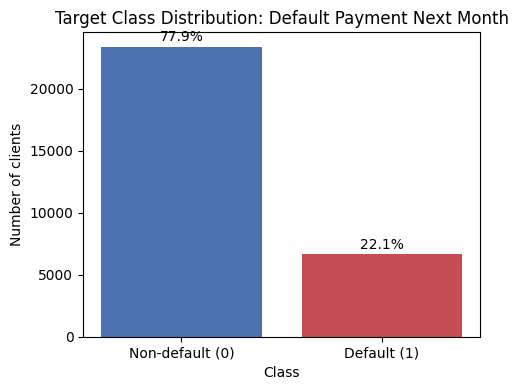

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Non-default (0)", "Default (1)"], target_counts.values, color=["#4C72B0", "#C44E52"])
ax.set_title("Target Class Distribution: Default Payment Next Month")
ax.set_ylabel("Number of clients")
ax.set_xlabel("Class")
for bar, pct in zip(bars, target_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()


**Why accuracy alone is misleading here:** a trivial classifier that predicts "no default"
for *every* client would already be correct ~77.9% of the time, purely by exploiting the class
imbalance, while catching **zero** actual defaulters — the exact clients a credit risk team
most needs to identify. A high accuracy score can therefore coexist with a model that is
operationally useless. This is why the primary evaluation metric adopted later in this project
is **F1-score for the positive (Default) class** — not accuracy — and why a majority-class
baseline is required to make this gap explicit and measurable rather than asserted.

### Leakage Audit

### Method
Explicitly enumerate every column and ask: *could this value only be known after the target
month's due date has passed?* This is a design-time audit (no code needs to run to answer it,
though the checks below confirm the structural facts the argument relies on).

### Findings
- **Target column** (`default payment next month`) is definitionally the outcome — obviously
  excluded from the feature set, verified by the column-name checks earlier and enforced later
  by the `X`/`y` split.
- **`ID`** carries no predictive information and is not a legitimate feature; retaining it risks
  a model spuriously keying on row order or ID-encoded artifacts. It **must be dropped** from
  the modeling feature set in Data Preparation below.
- **`PAY_0`…`PAY_6`, `BILL_AMT1`…`BILL_AMT6`, `PAY_AMT1`…`PAY_AMT6`** are all historical —
  they describe the **six months up to and including the most recent billing cycle**, all of
  which precede the target month's due date. None of these describe the target month's own
  outcome, so none of them are leakage by construction *in this dataset as provided*. This
  dataset does not contain any column that describes billing/payment behavior *after* the
  target month, so no additional post-period columns need to be excluded beyond `ID`.
- **No feature in this dataset is computed using statistics from the full dataset** at this
  point — `raw_data` is the untouched load. Any leakage risk from here onward would come from
  *procedure* (e.g., fitting a scaler before splitting), not from the raw columns themselves.
  The Train/Validation/Test Split and Preprocessing Pipeline sections later in this notebook
  enforce split-before-fit as a hard rule to prevent this failure mode.

### Decision / implication
The **only** structural exclusion required before modeling is `ID`. All other 23 non-target
columns are legitimate, pre-target-month predictors. The leakage risk in this project is
therefore primarily a *procedural* risk (fitting preprocessing on data outside the training
fold) rather than a *feature-selection* risk — which is why the Data Preparation, Split, and
Preprocessing Pipeline sections all reiterate the train-only-fit rule from different angles.


### Data Quality Summary Table

In [18]:
# Table 3: Quality audit (undocumented categories & missing values).
table3 = pd.DataFrame([
    ("Missing values (any column)", int(raw_data.isna().sum().sum()), "0.000%", "None — no imputation required"),
    ("Exact duplicate rows", int(n_dupes), f"{n_dupes/len(raw_data):.3%}", "None — no de-duplication required"),
    ("EDUCATION undocumented codes (0,5,6)", int(undocumented_education), f"{undocumented_education/len(raw_data):.3%}", "Merge into category 4 ('Others')"),
    ("MARRIAGE undocumented code (0)", int(undocumented_marriage), f"{undocumented_marriage/len(raw_data):.3%}", "Merge into category 3 ('Others')"),
    ("BILL_AMT negative values (any month)", int((raw_data[[f'BILL_AMT{i}' for i in range(1,7)]] < 0).any(axis=1).sum()), None, "Retain — valid overpayment/credit balance"),
    ("Non-predictive ID column", 1, None, "Drop from feature matrix"),
], columns=["issue", "affected_rows_or_columns", "pct_of_rows", "decision"])
table3


,issue,affected_rows_or_columns,pct_of_rows,decision
0,Missing values (any column),0,0.000%,None — no imputation required
1,Exact duplicate rows,0,0.000%,None — no de-duplication required
2,"EDUCATION undocumented codes (0,5,6)",345,1.150%,Merge into category 4 ('Others')
3,MARRIAGE undocumented code (0),54,0.180%,Merge into category 3 ('Others')
4,BILL_AMT negative values (any month),1930,None,Retain — valid overpayment/credit balance
5,Non-predictive ID column,1,None,Drop from feature matrix


### Data Quality Summary: Result & Decision
- Structural integrity confirmed: correct shape, no missing values, no exact duplicates.
- Two demographic columns contain undocumented category codes that will be consolidated into
  an "Others" bucket during data preparation.
- `PAY_X` sentinel values (-2, -1) are semantically distinct from ordinary delay counts and will
  be handled explicitly, not left as raw integers fed into a linear model unexamined.
- Negative `BILL_AMT` values are valid (overpayment/credit) and are retained.
- The only column requiring exclusion from the feature matrix on leakage/non-predictive grounds
  is `ID`.
- These decisions collectively define the scope of the Data Preparation section that follows.


## Data Preparation

### Objective
Turn the documented findings from the quality audit above into a concrete, reproducible set of
cleaning steps — and be explicit about *which* of those steps are safe to apply to the whole
dataset now (fixed, rule-based recodes that don't estimate anything from the data) versus which
steps must wait until after the train/validation/test split (anything that estimates a
parameter — a mean, a variance, a category's frequency — from the data itself).

### Method
A `clean_data` frame is created from `raw_data`; every change from this point on is applied to
`clean_data`, never back onto `raw_data`, so the original load is always available for
comparison. `raw_data`, `clean_data`, the eventual feature matrix, and the model pipelines are
kept as conceptually distinct objects throughout the notebook.


In [19]:
clean_data = raw_data.copy()
print(f"clean_data created from raw_data. Shape: {clean_data.shape}")


clean_data created from raw_data. Shape: (30000, 25)


### ID Handling
`ID` is a row identifier with no predictive content. It is not needed for any analysis in this
notebook and will never be passed into a model's feature matrix. Rather than delete it outright
(it is occasionally useful for tracing a specific row during error analysis later), it is simply
excluded from the feature list used to build `X` once we reach the train/validation/test split
and preprocessing pipeline.

In [20]:
NON_FEATURE_COLS = ["ID", TARGET_COL]
print(f"Columns excluded from the modeling feature matrix: {NON_FEATURE_COLS}")


Columns excluded from the modeling feature matrix: ['ID', 'default payment next month']


### Target Verification
Before trusting any downstream metric, confirm the target really is a clean binary 0/1 column —
not, say, a float with unexpected values, or a column containing nulls.

In [21]:
target_values = sorted(clean_data[TARGET_COL].unique().tolist())
assert target_values == [0, 1], f"Expected target values [0, 1], found: {target_values}"
assert clean_data[TARGET_COL].isna().sum() == 0, "Target contains missing values."
clean_data[TARGET_COL] = clean_data[TARGET_COL].astype(int)
print(f"Target verified: values = {target_values}, dtype = {clean_data[TARGET_COL].dtype}, "
      f"missing = {clean_data[TARGET_COL].isna().sum()}")


Target verified: values = [0, 1], dtype = int64, missing = 0


### Undocumented Category Handling
The quality audit above found undocumented codes in `EDUCATION` (0, 5, 6 — outside the
documented 1–4 range) and `MARRIAGE` (0 — outside the documented 1–3 range). Both are merged
into their respective "Others" category (`EDUCATION` code 4, `MARRIAGE` code 3).

This recode is a **fixed, rule-based mapping** — it does not compute any statistic (mean,
frequency, or otherwise) from the data, so it is safe to apply to the entire dataset now, before
the train/validation/test split, without introducing leakage. This is different in kind from
scaling or one-hot encoding, which *do* estimate parameters from the data and must therefore
wait until after the split (see the two subsections immediately below, and the Preprocessing
Pipeline section later in this notebook).

In [22]:
print("EDUCATION before recoding:")
print(clean_data["EDUCATION"].value_counts().sort_index())

clean_data["EDUCATION"] = clean_data["EDUCATION"].replace({0: 4, 5: 4, 6: 4})

print("\nEDUCATION after recoding (0, 5, 6 -> 4 'Others'):")
print(clean_data["EDUCATION"].value_counts().sort_index())


EDUCATION before recoding:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

EDUCATION after recoding (0, 5, 6 -> 4 'Others'):
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64


In [23]:
print("MARRIAGE before recoding:")
print(clean_data["MARRIAGE"].value_counts().sort_index())

clean_data["MARRIAGE"] = clean_data["MARRIAGE"].replace({0: 3})

print("\nMARRIAGE after recoding (0 -> 3 'Others'):")
print(clean_data["MARRIAGE"].value_counts().sort_index())


MARRIAGE before recoding:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

MARRIAGE after recoding (0 -> 3 'Others'):
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


### Categorical Encoding (decision documented here, applied later)
`SEX`, `EDUCATION`, and `MARRIAGE` are nominal categorical variables stored as integer codes —
there is no meaningful order between "married" and "single", for example, so they must **not**
be fed into a linear model as raw integers. They will be one-hot encoded
(`OneHotEncoder(handle_unknown="ignore")`) inside the modeling pipeline. One-hot encoding is
deferred rather than applied here because, in principle, an encoder could be configured to treat
rare categories specially based on their observed frequency — a data-derived decision — so to
keep the rule airtight, all encoding is fit strictly on the training fold once the split exists.

In [24]:
NOMINAL_CATEGORICAL_COLS = ["SEX", "EDUCATION", "MARRIAGE"]
print(f"Nominal categorical columns to one-hot encode later: {NOMINAL_CATEGORICAL_COLS}")


Nominal categorical columns to one-hot encode later: ['SEX', 'EDUCATION', 'MARRIAGE']


### Numeric Scaling (decision documented here, applied later)
`LIMIT_BAL`, `AGE`, the `BILL_AMT*` columns, and the `PAY_AMT*` columns are on very different
numeric scales (e.g. `AGE` in tens, `LIMIT_BAL` in hundreds of thousands). Distance- and
gradient-sensitive models — Logistic Regression in particular — need these standardized. Scaling
parameters (mean and standard deviation) are estimated from the data, so — unlike the
category-code recoding above — this step is explicitly deferred until after the
train/validation/test split, and will be fit only on the training fold inside the preprocessing
pipeline.

In [25]:
NUMERIC_COLS = [
    "LIMIT_BAL", "AGE",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
]
print(f"Numeric columns to standardize later ({len(NUMERIC_COLS)}): {NUMERIC_COLS}")


Numeric columns to standardize later (14): ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


### Outliers
### Objective
Decide, column by column, whether extreme values represent genuine (if unusual) financial
observations or data errors — rather than mechanically deleting every statistical outlier, which
would risk throwing away exactly the high-limit, high-balance clients a credit risk model most
needs to learn from.

### Method
Use the IQR rule (values beyond 1.5x the interquartile range from Q1/Q3) purely as a
*flagging* mechanism on the key numeric columns, then inspect what those flagged rows actually
look like before deciding what, if anything, to do about them.

In [26]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum())

outlier_summary = pd.DataFrame({
    "column": NUMERIC_COLS,
    "iqr_flagged_count": [iqr_outlier_count(clean_data[c]) for c in NUMERIC_COLS],
})
outlier_summary["iqr_flagged_pct"] = (outlier_summary["iqr_flagged_count"] / len(clean_data) * 100).round(2)
outlier_summary.sort_values("iqr_flagged_pct", ascending=False)


,column,iqr_flagged_count,iqr_flagged_pct
11,PAY_AMT4,2994,9.98
13,PAY_AMT6,2958,9.86
12,PAY_AMT5,2945,9.82
8,PAY_AMT1,2745,9.15
6,BILL_AMT5,2725,9.08
9,PAY_AMT2,2714,9.05
7,BILL_AMT6,2693,8.98
5,BILL_AMT4,2622,8.74
10,PAY_AMT3,2598,8.66
4,BILL_AMT3,2469,8.23


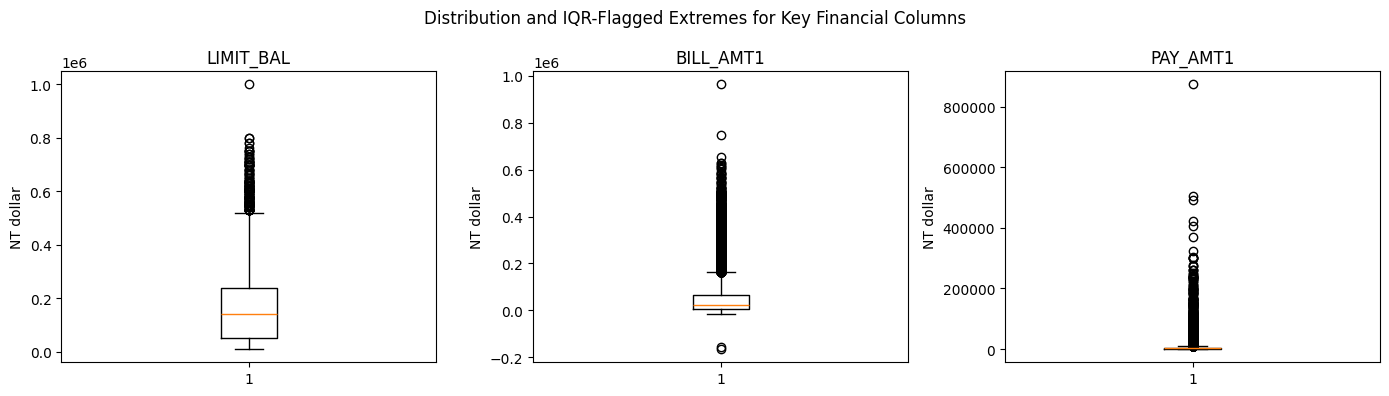

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"]):
    ax.boxplot(clean_data[col], vert=True)
    ax.set_title(col)
    ax.set_ylabel("NT dollar")
fig.suptitle("Distribution and IQR-Flagged Extremes for Key Financial Columns")
plt.tight_layout()
plt.show()


**Interpretation and decision:** the IQR rule flags a meaningful share of rows in almost
every bill/payment column, which is expected for financial amount data — these distributions are
right-skewed by nature (most clients carry modest balances, a minority carry very large ones),
not because the data is faulty. A very large `BILL_AMT1` or `PAY_AMT1` is a legitimate,
informative observation about a client's financial behavior — plausibly *more* relevant to
default risk than a typical value, not less. Deleting these rows would both discard real signal
and bias the training data away from the exact high-usage clients a risk model exists to assess.

**Decision:** no rows are removed on outlier grounds. Extreme financial magnitudes are retained
as-is. Scale sensitivity for Logistic Regression is instead handled through standardization
(documented above), and tree-based ensembles are naturally robust to the raw magnitude of these
outliers by construction (they split on rank/threshold, not distance).

### Repayment Status (PAY_X) Recoding
### Objective
`PAY_0`…`PAY_6` mix three qualitatively different situations into one integer column: no
revolving balance to speak of (-2), the balance was paid in full (-1), and a small positive
integer count of months delinquent (1–9). Feeding this column into a linear model as a raw
integer implicitly assumes -2 < -1 < 0 < 1 < 2 ... represents a single ordered "risk" scale,
which is not true — being at -2 does not mean "less delinquent than -1".

### Method
Create a recoded companion column for each `PAY_X` that collapses every non-delinquent state
(-2, -1, 0) to a single value of 0, and leaves the delinquency-month counts (1–9) unchanged.
The result is a column that is genuinely ordinal: 0 means "not currently delinquent" and any
value above 0 is a monotonically increasing count of months behind. The original `PAY_X` columns
are kept unchanged alongside the recoded versions, since the original sentinel-coded values are
still useful for exploratory analysis (e.g. distinguishing "no consumption" from "paid in full").

In [28]:
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
pay_recoded_cols = [f"{c}_DELAY" for c in pay_cols]

for original_col, recoded_col in zip(pay_cols, pay_recoded_cols):
    clean_data[recoded_col] = clean_data[original_col].clip(lower=0)

print("Example — PAY_0 vs. PAY_0_DELAY value counts:")
comparison = pd.DataFrame({
    "PAY_0 (original)": clean_data["PAY_0"].value_counts().sort_index(),
    "PAY_0_DELAY (recoded)": clean_data["PAY_0_DELAY"].value_counts().sort_index(),
}).fillna(0).astype(int)
comparison


Example — PAY_0 vs. PAY_0_DELAY value counts:


,PAY_0 (original),PAY_0_DELAY (recoded)
-2,2759,0
-1,5686,0
0,14737,23182
1,3688,3688
2,2667,2667
3,322,322
4,76,76
5,26,26
6,11,11
7,9,9


**Decision:** the `*_DELAY` columns (0 = not delinquent, 1–9 = months delinquent) are the
versions used as model inputs going forward, since they express a genuinely ordinal quantity.
The original `PAY_X` columns are retained in `clean_data` for exploratory analysis, where the
distinction between "no consumption" and "paid in full" is informative on its own, but are not
directly fed into the final feature matrix in place of their recoded counterparts.

### Data Preparation Summary Table

In [29]:
# Preprocessing & feature engineering decisions made so far.
table4 = pd.DataFrame([
    ("ID", "Exclude from feature matrix", "Non-predictive identifier; carries no signal"),
    ("default payment next month", "Verified binary 0/1, cast to int", "Target integrity check"),
    ("EDUCATION", "Recode {0,5,6} -> 4 ('Others')", "Undocumented codes; rule-based, safe pre-split"),
    ("MARRIAGE", "Recode {0} -> 3 ('Others')", "Undocumented code; rule-based, safe pre-split"),
    ("SEX / EDUCATION / MARRIAGE", "One-hot encode (deferred)", "Nominal categories; encoder fit on training fold only"),
    ("LIMIT_BAL, AGE, BILL_AMT*, PAY_AMT*", "Standardize (deferred)", "Different scales; scaler fit on training fold only"),
    ("BILL_AMT* / PAY_AMT* extreme values", "Retain, no removal", "Right-skewed but financially plausible; informative for risk"),
    ("PAY_0..PAY_6", "Add *_DELAY recode: clip(lower=0)", "Collapses non-delinquent sentinels to 0; preserves ordinal delay count"),
], columns=["column(s)", "decision", "justification"])
table4


,column(s),decision,justification
0,ID,Exclude from feature matrix,Non-predictive identifier; carries no signal
1,default payment next month,"Verified binary 0/1, cast to int",Target integrity check
2,EDUCATION,"Recode {0,5,6} -> 4 ('Others')","Undocumented codes; rule-based, safe pre-split"
3,MARRIAGE,Recode {0} -> 3 ('Others'),"Undocumented code; rule-based, safe pre-split"
4,SEX / EDUCATION / MARRIAGE,One-hot encode (deferred),Nominal categories; encoder fit on training fo...
5,"LIMIT_BAL, AGE, BILL_AMT*, PAY_AMT*",Standardize (deferred),Different scales; scaler fit on training fold ...
6,BILL_AMT* / PAY_AMT* extreme values,"Retain, no removal",Right-skewed but financially plausible; inform...
7,PAY_0..PAY_6,Add *_DELAY recode: clip(lower=0),Collapses non-delinquent sentinels to 0; prese...


## Exploratory Data Analysis

### Objective
Every plot and table in this section exists to answer a specific question about how a variable
relates to default risk — not as a gallery of generic charts. Each subsection ends with a short
takeaway describing what the result implies for modeling choices later in this notebook.


In [30]:
import seaborn as sns
sns.set_style("whitegrid")


### Numerical Variables
### Method
Examine summary statistics, distribution shape, and — critically — how each variable's
distribution differs between defaulters and non-defaulters, for the numerical variables most
likely to carry default-risk signal: `LIMIT_BAL`, `AGE`, `PAY_0` (most recent repayment status),
`BILL_AMT1`, and `PAY_AMT1`.

In [31]:
key_numeric_vars = ["LIMIT_BAL", "AGE", "PAY_0", "BILL_AMT1", "PAY_AMT1"]
clean_data[key_numeric_vars + [TARGET_COL]].describe().T


,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.0,1000000.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.0,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.0,8.0
BILL_AMT1,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.0,964511.0
PAY_AMT1,30000.0,5663.580500,16563.280354,0.0,1000.00,2100.0,5006.0,873552.0
default payment next month,30000.0,0.221200,0.415062,0.0,0.00,0.0,0.0,1.0


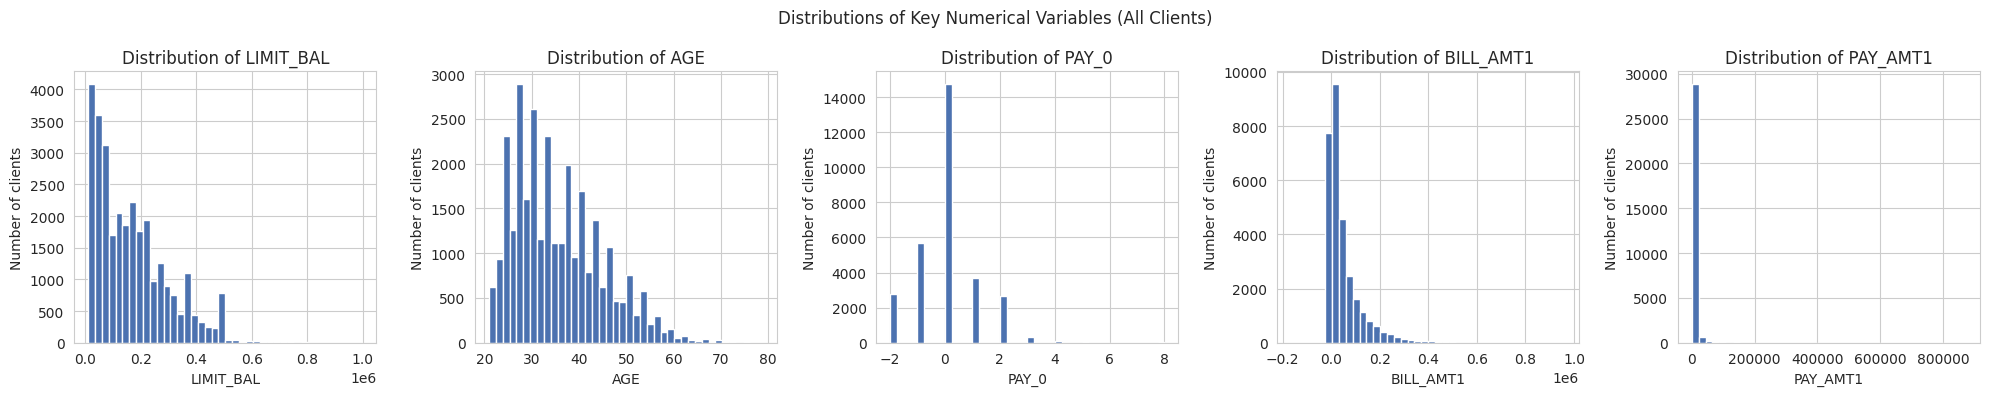

In [32]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, key_numeric_vars):
    ax.hist(clean_data[col], bins=40, color="#4C72B0", edgecolor="white")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Number of clients")
fig.suptitle("Distributions of Key Numerical Variables (All Clients)")
plt.tight_layout()
plt.show()


/tmp/ipykernel_1357/4042922493.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_class, labels=["Non-default", "Default"])
/tmp/ipykernel_1357/4042922493.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_class, labels=["Non-default", "Default"])
/tmp/ipykernel_1357/4042922493.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_class, labels=["Non-default", "Default"])
/tmp/ipykernel_1357/4042922493.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be drop

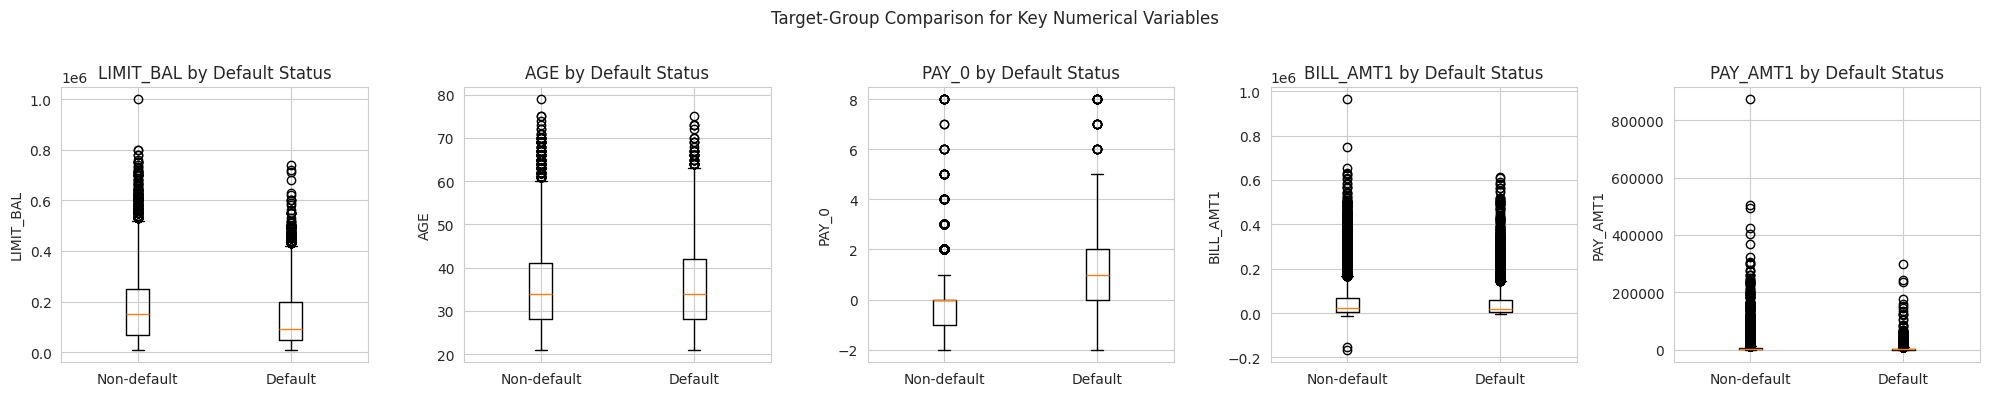

In [33]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, key_numeric_vars):
    data_by_class = [clean_data.loc[clean_data[TARGET_COL] == cls, col] for cls in [0, 1]]
    ax.boxplot(data_by_class, labels=["Non-default", "Default"])
    ax.set_title(f"{col} by Default Status")
    ax.set_ylabel(col)
fig.suptitle("Target-Group Comparison for Key Numerical Variables")
plt.tight_layout()
plt.show()


**Result:** `PAY_0` shows the clearest separation between classes — defaulters are
concentrated at higher (more delinquent) values, while non-defaulters cluster at 0 or below.
`LIMIT_BAL` tends to be lower among defaulters, consistent with lower credit limits being
assigned to higher-risk clients in the first place. `AGE`, `BILL_AMT1`, and `PAY_AMT1` show much
subtler differences between the two groups on their own.

**Decision / implication:** `PAY_0` (and by extension the other recoded `*_DELAY` repayment
columns) is expected to be one of the most influential predictors — this will be checked
formally against the feature-importance results once models are trained. Variables with weak
univariate separation, like `AGE`, are not discarded at this stage — they may still contribute
through interactions that a tree-based model can exploit, which is examined next.

### Categorical Variables and Default Rate
### Method
For each categorical/ordinal grouping variable, compute the default *rate* (not just the raw
count) within each category, since raw counts alone don't reveal whether a category is
disproportionately risky.

In [34]:
def default_rate_table(df, group_col):
    table = df.groupby(group_col)[TARGET_COL].agg(["count", "mean"]).rename(columns={"mean": "default_rate"})
    table["default_rate_pct"] = (table["default_rate"] * 100).round(2)
    return table.drop(columns="default_rate")

print("Default rate by SEX (1=male, 2=female):")
display(default_rate_table(clean_data, "SEX"))

print("Default rate by EDUCATION (1=grad school, 2=university, 3=high school, 4=others):")
display(default_rate_table(clean_data, "EDUCATION"))

print("Default rate by MARRIAGE (1=married, 2=single, 3=others):")
display(default_rate_table(clean_data, "MARRIAGE"))

print("Default rate by PAY_0 (repayment status, most recent month):")
display(default_rate_table(clean_data, "PAY_0"))


Default rate by SEX (1=male, 2=female):


,count,default_rate_pct
SEX,,
1,11888,24.17
2,18112,20.78


Default rate by EDUCATION (1=grad school, 2=university, 3=high school, 4=others):


,count,default_rate_pct
EDUCATION,,
1,10585,19.23
2,14030,23.73
3,4917,25.16
4,468,7.05


Default rate by MARRIAGE (1=married, 2=single, 3=others):


,count,default_rate_pct
MARRIAGE,,
1,13659,23.47
2,15964,20.93
3,377,23.61


Default rate by PAY_0 (repayment status, most recent month):


,count,default_rate_pct
PAY_0,,
-2,2759,13.23
-1,5686,16.78
0,14737,12.81
1,3688,33.95
2,2667,69.14
3,322,75.78
4,76,68.42
5,26,50.00
6,11,54.55


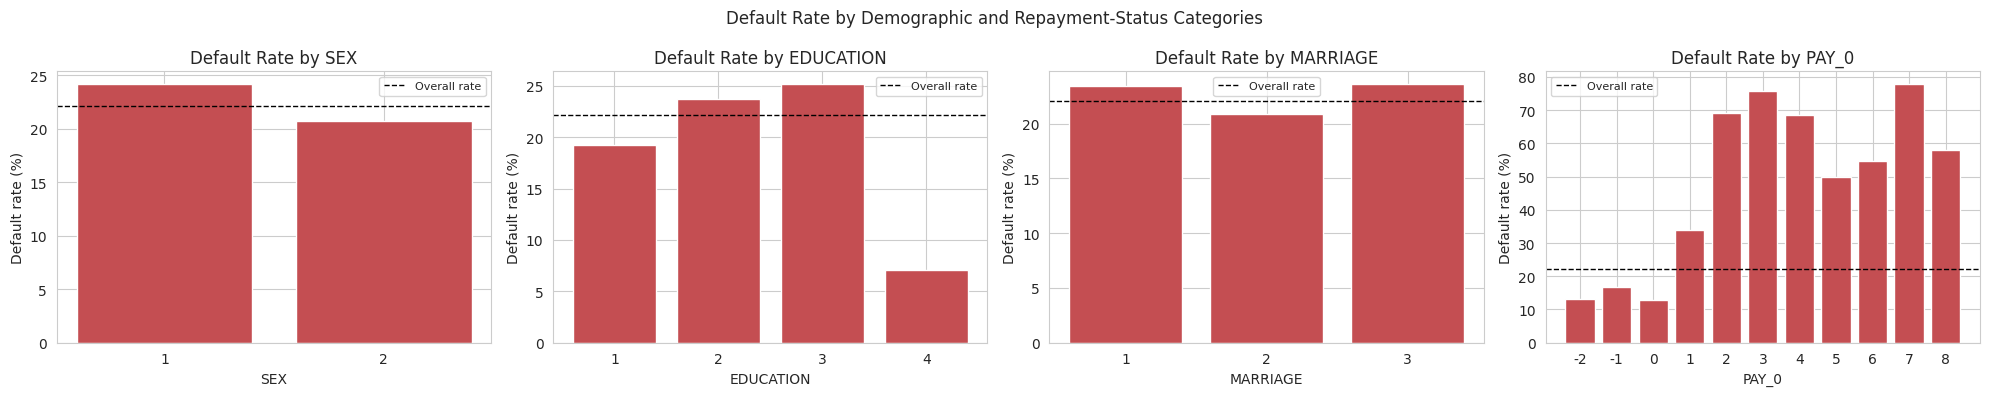

In [35]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, col in zip(axes, ["SEX", "EDUCATION", "MARRIAGE", "PAY_0"]):
    rates = clean_data.groupby(col)[TARGET_COL].mean() * 100
    ax.bar(rates.index.astype(str), rates.values, color="#C44E52")
    ax.set_title(f"Default Rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Default rate (%)")
    ax.axhline(clean_data[TARGET_COL].mean() * 100, color="black", linestyle="--", linewidth=1,
               label="Overall rate")
    ax.legend(fontsize=8)
fig.suptitle("Default Rate by Demographic and Repayment-Status Categories")
plt.tight_layout()
plt.show()


**Result:** default rate varies only modestly across `SEX`, `EDUCATION`, and `MARRIAGE`
relative to the overall ~22.1% baseline — none of these demographic splits isolates a
dramatically higher- or lower-risk subgroup on their own. `PAY_0`, in contrast, shows a steep,
almost monotonic increase in default rate as the repayment-status code rises from "not
delinquent" toward higher delay counts — clients several months behind default at a far higher
rate than clients current on payments.

**Decision / implication:** this reinforces the earlier univariate finding — recent repayment
status carries far more default-risk signal than static demographics. Demographic variables are
retained as model inputs (rare category effects or interactions may still matter, and dropping
them outright would also remove information a stakeholder may reasonably want reported on), but
the model is not expected to lean on them heavily, and any large demographic-driven importance
in the final model would deserve extra scrutiny for the fairness reasons noted earlier.

### Multivariate Analysis
### Method
Look at combinations of variables that a univariate view can hide: how credit limit interacts
with education, how age interacts with marital status, how consecutive months of repayment
status move together, and how a payment-to-bill ratio relates to default.

In [36]:
limit_by_education = clean_data.groupby("EDUCATION").agg(
    avg_limit_bal=("LIMIT_BAL", "mean"),
    default_rate_pct=(TARGET_COL, lambda s: s.mean() * 100),
).round(1)
limit_by_education


,avg_limit_bal,default_rate_pct
EDUCATION,,
1,212956.1,19.2
2,147062.4,23.7
3,126550.3,25.2
4,181316.2,7.1


In [37]:
age_bins = pd.cut(clean_data["AGE"], bins=[20, 30, 40, 50, 60, 80],
                   labels=["21-30", "31-40", "41-50", "51-60", "61+"])
age_marriage_default = clean_data.assign(AGE_GROUP=age_bins).groupby(["AGE_GROUP", "MARRIAGE"], observed=True)[TARGET_COL].mean().unstack() * 100
age_marriage_default = age_marriage_default.round(1)
age_marriage_default.columns = ["Married", "Single", "Others"]
age_marriage_default


,Married,Single,Others
AGE_GROUP,,,
21-30,25.9,21.7,25.0
31-40,21.7,19.1,15.8
41-50,23.5,22.5,25.5
51-60,26.8,19.4,29.7
61+,26.7,28.6,20.0


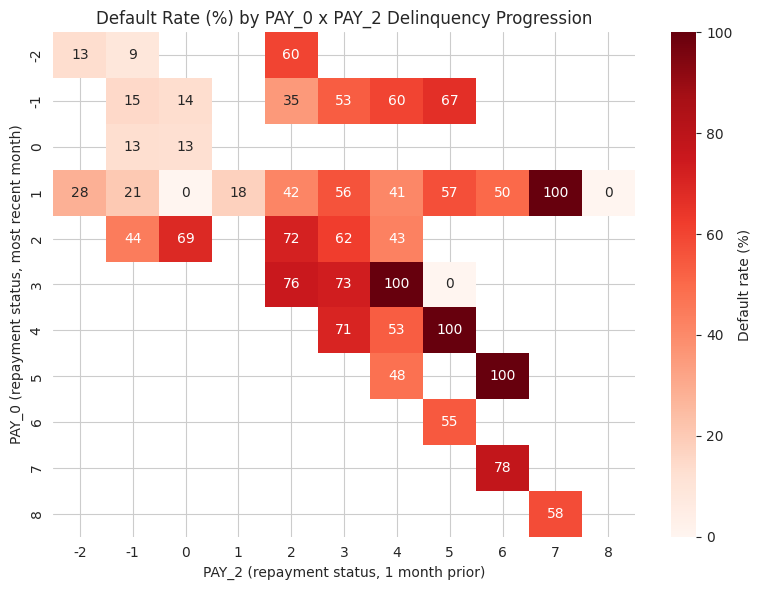

In [38]:
pay_progression = pd.crosstab(clean_data["PAY_0"], clean_data["PAY_2"], values=clean_data[TARGET_COL], aggfunc="mean") * 100

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pay_progression, annot=True, fmt=".0f", cmap="Reds", ax=ax, cbar_kws={"label": "Default rate (%)"})
ax.set_title("Default Rate (%) by PAY_0 x PAY_2 Delinquency Progression")
ax.set_xlabel("PAY_2 (repayment status, 1 month prior)")
ax.set_ylabel("PAY_0 (repayment status, most recent month)")
plt.tight_layout()
plt.show()


/tmp/ipykernel_1357/1343729791.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_class, labels=["Non-default", "Default"])


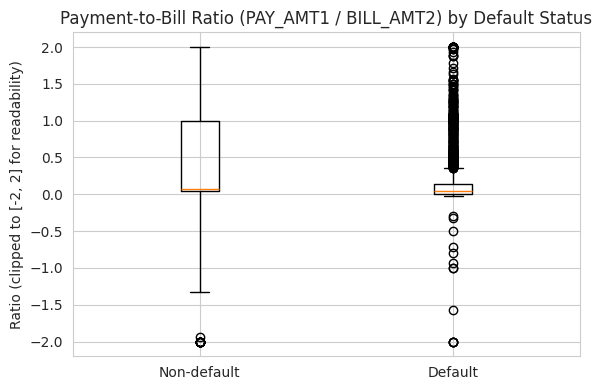

In [39]:
# Payment-to-bill ratio: exploratory only in this section (row-wise, not a fitted
# statistic, so safe to compute globally for visualization; the modeling version of
# this ratio is defined and attached to the feature matrix in Feature Engineering below,
# where it is treated consistently across the train/validation/test split).
eda_pay_to_bill_ratio = clean_data["PAY_AMT1"] / (clean_data["BILL_AMT2"] + 1e-5)
eda_pay_to_bill_ratio_clipped = eda_pay_to_bill_ratio.clip(-2, 2)  # clip extreme ratios purely for plot readability

fig, ax = plt.subplots(figsize=(6, 4))
data_by_class = [eda_pay_to_bill_ratio_clipped[clean_data[TARGET_COL] == cls] for cls in [0, 1]]
ax.boxplot(data_by_class, labels=["Non-default", "Default"])
ax.set_title("Payment-to-Bill Ratio (PAY_AMT1 / BILL_AMT2) by Default Status")
ax.set_ylabel("Ratio (clipped to [-2, 2] for readability)")
plt.tight_layout()
plt.show()


**Result:**
- Average credit limit varies by education level, and default rate differs modestly across the
  same groups — clients with lower average limits show a somewhat higher default rate, but
  education alone does not create a sharp risk split.
- Default rate rises with age within some marital-status groups but not uniformly across all of
  them — an interaction effect that a purely linear, non-interacting model would miss unless it
  is given engineered interaction terms or a tree-based structure that can find splits on its own.
- The `PAY_0` x `PAY_2` heatmap shows default rate rising sharply along the diagonal where a
  client is delinquent in *both* recent months — consecutive-month delinquency compounds risk
  more than either month alone.
- Clients who default tend to show lower payment-to-bill ratios (paying back a smaller share of
  what they were billed), matching financial intuition.

**Decision / implication:** the compounding effect visible in the `PAY_0` x `PAY_2` heatmap
motivates the delinquency-summary features (e.g. a count of delinquent months across all six
repayment columns) planned for the Feature Engineering section, since a single month's status
alone under-represents a client's overall trajectory. The payment-to-bill ratio is confirmed as
a worthwhile engineered feature rather than a purely exploratory curiosity.

### Correlation Among Numerical Variables
### Method
Compute pairwise correlations among the numeric predictors, with particular attention to the six
`BILL_AMT` columns, which describe the same account's balance across consecutive months and are
likely to move together strongly.

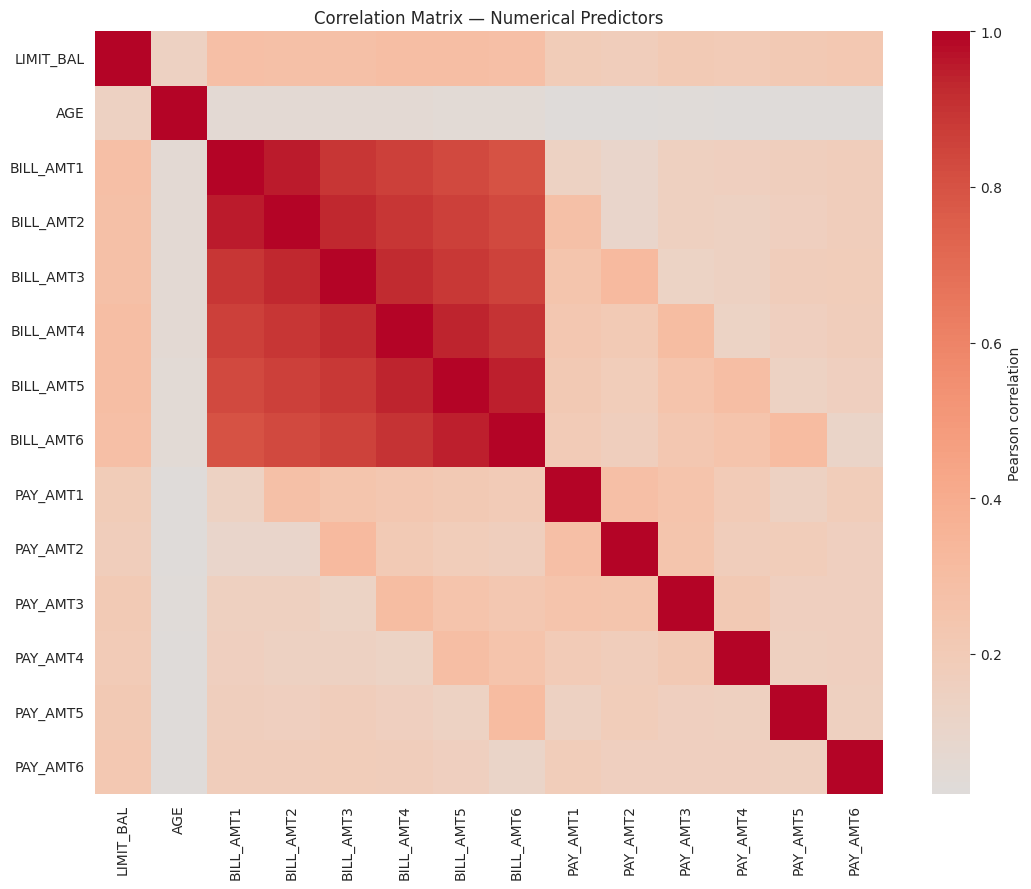

Correlation among BILL_AMT1..BILL_AMT6:


,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
BILL_AMT1,1.00,0.95,0.89,0.86,0.83,0.80
BILL_AMT2,0.95,1.00,0.93,0.89,0.86,0.83
BILL_AMT3,0.89,0.93,1.00,0.92,0.88,0.85
BILL_AMT4,0.86,0.89,0.92,1.00,0.94,0.90
BILL_AMT5,0.83,0.86,0.88,0.94,1.00,0.95
BILL_AMT6,0.80,0.83,0.85,0.90,0.95,1.00


In [40]:
corr_cols = ["LIMIT_BAL", "AGE"] + [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]
corr_matrix = clean_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0, ax=ax,
            cbar_kws={"label": "Pearson correlation"})
ax.set_title("Correlation Matrix — Numerical Predictors")
plt.tight_layout()
plt.show()

bill_amt_corr = clean_data[[f"BILL_AMT{i}" for i in range(1, 7)]].corr()
print("Correlation among BILL_AMT1..BILL_AMT6:")
bill_amt_corr.round(2)


**Result:** the `BILL_AMT1`…`BILL_AMT6` columns are very highly correlated with each other
(consistent with the fact that a client's outstanding balance tends to persist from one month to
the next), while `PAY_AMT` columns and `LIMIT_BAL`/`AGE` show much weaker correlations with the
rest of the numeric predictors.

**Decision / implication:** this multicollinearity matters differently for the two model
families used later in this notebook. For **Logistic Regression**, highly correlated inputs
inflate coefficient variance and make individual coefficients unstable and harder to interpret
in isolation — though it does not necessarily hurt the model's overall predictive performance,
and L2 regularization (used later) further stabilizes the fit. For **tree-based ensembles**
(Random Forest / gradient boosting), correlated features are not a validity problem in the same
way — a tree simply picks one of several redundant, correlated candidates to split on at each
node — though correlated features can dilute individual feature-importance scores across
several redundant columns rather than concentrating credit on one. Both facts are kept in mind
when interpreting each model's coefficients/importances later in this notebook.

---
## Next Steps

This notebook currently implements: project framing and objective, dataset documentation,
data loading with a live-fetch-and-verified-fallback strategy, the full data-quality and
leakage audit, data preparation (ID handling, target verification, undocumented-category
recoding, the outlier review, and the repayment-status recoding), and exploratory data analysis
(univariate, categorical default-rate, multivariate, and correlation analysis).

Not yet implemented: ratio/delinquency feature engineering, the stratified train/validation/test
split, the preprocessing pipeline (encoding + scaling fit on the training fold), the
baseline/Logistic Regression/ensemble models, threshold analysis, model comparison and final
selection, the single held-out test evaluation, diagnostics, feature importance, and the final
conclusion. These will be added next.
